<a href="https://colab.research.google.com/github/saturnsz/Machine-Learning-LnTCamp-Collab-/blob/main/LnTCamp_Regresii_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**LOAD DATA**

In [ ]:
db_path = '/content/drive/MyDrive/superstore (1).sqlite'
conn = sqlite3.connect(db_path)

In [ ]:
query = """
    SELECT
        oi.profit, oi.sales, oi.discount, oi.quantity, oi.shipping_cost,
        o.ship_mode, o.order_priority,
        c.segment,
        l.market, l.region,
        p.category, p.sub_category
    FROM order_items oi
    JOIN orders o ON oi.order_key = o.order_key
    JOIN dim_customers c ON o.customer_id = c.customer_id
    JOIN dim_locations l ON o.location_id = l.location_id
    JOIN dim_products p ON oi.product_id = p.product_id
"""
df = pd.read_sql_query(query, conn)
conn.close()
print("Data berhasil diload. Ukuran awal:", df.shape)

Data berhasil diload. Ukuran awal: (51290, 12)


In [ ]:
display(df.head())

,profit,sales,discount,quantity,shipping_cost,ship_mode,order_priority,segment,market,region,category,sub_category
0,4.56,13.0,0.0,3,1.033,Standard Class,Medium,Consumer,LATAM,North,Office Supplies,Labels
1,90.72,252.0,0.0,8,13.449,Standard Class,Medium,Consumer,LATAM,South,Furniture,Furnishings
2,54.08,193.0,0.0,2,9.627,Standard Class,Medium,Consumer,LATAM,South,Furniture,Bookcases
3,4.96,35.0,0.0,4,1.371,Standard Class,Medium,Consumer,LATAM,South,Office Supplies,Binders
4,11.44,72.0,0.0,2,3.787,Standard Class,Medium,Consumer,LATAM,South,Office Supplies,Art


**PEMBERSIHAN OUTLIER**

In [ ]:
# Menghapus 1% data teratas yang bernilai ekstrem pada sales dan profit
q_sales = df['sales'].quantile(0.99)
q_profit_high = df['profit'].quantile(0.99)
q_profit_low = df['profit'].quantile(0.01)

df = df[(df['sales'] < q_sales) &
        (df['profit'] < q_profit_high) &
        (df['profit'] > q_profit_low)]
print("Data setelah outlier dibuang:", df.shape)

Data setelah outlier dibuang: (50057, 12)


**FEATURE ENGINEERING**

In [ ]:
df['shipping_cost_ratio'] = df['shipping_cost'] / df['sales']
df['discount_impact'] = df['discount'] * df['sales']
df['total_cost_spent'] = df['sales'] + df['shipping_cost']

**PREPROCESSING (ENCODING & SCALING)**

In [ ]:
# Pisahkan Target (y) dan Fitur (X)
y = df['profit']
X = df.drop(columns=['profit'])

# One-Hot Encoding untuk kolom teks (kategorikal)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Penanganan nilai Infinity (Inf) dan NaN yang muncul akibat pembagian (fitur engineering)
# Mengganti inf dengan NaN lalu menghapus baris yang mengandung NaN
X_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)
y = y[X_encoded.notna().all(axis=1)]
X_encoded.dropna(inplace=True)

# Train-Test Split (80% Belajar, 20% Ujian)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Standarisasi Skala (Scaling) khusus kolom angka
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing selesai. Data siap digunakan.")

Preprocessing selesai. Data siap digunakan.


In [ ]:
print("\nMemulai pencarian parameter terbaik XGBoost... (Tunggu sebentar)")

# Inisialisasi model dasar
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

# Daftar parameter yang mau diuji
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [5, 7, 9],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Proses pencarian
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=15,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42
)

# Latih model dengan berbagai kombinasi
random_search.fit(X_train_scaled, y_train)

# Ambil model terbaik
best_xgb = random_search.best_estimator_
print("\nKombinasi Parameter Terbaik:", random_search.best_params_)


Memulai pencarian parameter terbaik XGBoost... (Tunggu sebentar)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Kombinasi Parameter Terbaik: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}



--- HASIL EVALUASI XGBOOST ---
R-Squared (R2): 0.6262
Mean Absolute Error (MAE): $26.67
Root Mean Squared Error (RMSE): $52.52


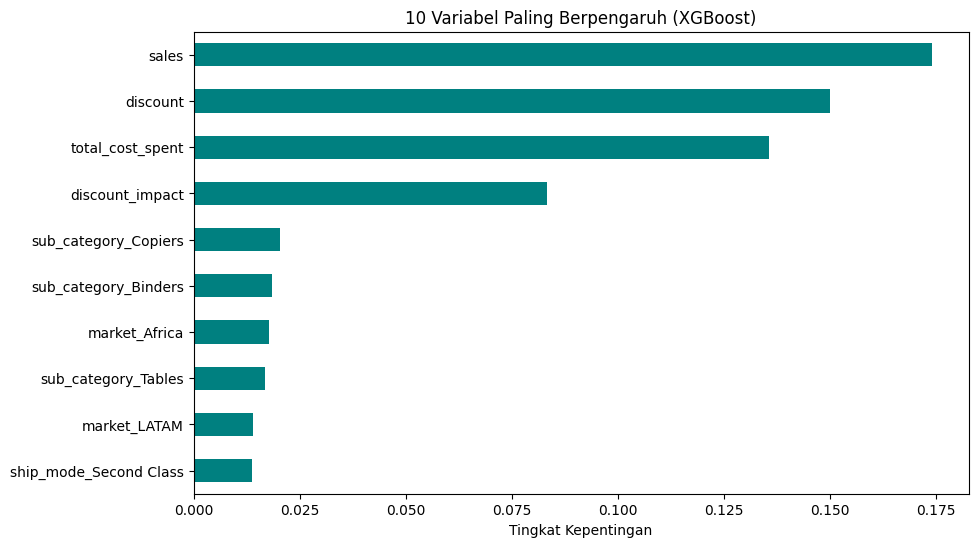

In [ ]:
y_pred_xgb = best_xgb.predict(X_test_scaled)

# Hitung Metrik
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\n--- HASIL EVALUASI XGBOOST ---")
print(f"R-Squared (R2): {r2_xgb:.4f}")
print(f"Mean Absolute Error (MAE): ${mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_xgb:.2f}")

# Visualisasi 10 Fitur Paling Berpengaruh
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(best_xgb.feature_importances_, index=X_train_scaled.columns)
feature_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('10 Variabel Paling Berpengaruh (XGBoost)')
plt.xlabel('Tingkat Kepentingan')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Menghitung probabilitas untuk ROC-AUC
y_pred_proba = xgb_classifier.predict_proba(X_test_scaled_clf)[:, 1]
roc_auc = roc_auc_score(y_test_clf, y_pred_proba)

print(f"Skor ROC-AUC: {roc_auc:.4f}")

Skor ROC-AUC: 0.9566


In [ ]:
import pandas as pd

# ==========================================
# 1. SIMULASI INPUT USER (DARI WEB FORM NANTINYA)
# ==========================================
# Bayangkan user mengetik angka dan memilih dropdown di web,
# lalu datanya masuk ke sistem dalam bentuk seperti ini:
user_input = {
    'sales': [2000],              # Harga jual $2000
    'discount': [0.4],            # Diskon 40% (0.4)
    'quantity': [5],              # Beli 5 barang
    'shipping_cost': [150],       # Ongkos kirim $150
    'ship_mode': ['Standard Class'],
    'order_priority': ['Medium'],
    'segment': ['Corporate'],
    'market': ['APAC'],
    'region': ['Southeast Asia'],
    'category': ['Furniture'],
    'sub_category': ['Tables']
}

# Ubah input menjadi DataFrame
df_input = pd.DataFrame(user_input)
print("1. Data Input User:")
display(df_input)


# ==========================================
# 2. FEATURE ENGINEERING (Sama seperti training)
# ==========================================
df_input['shipping_cost_ratio'] = df_input['shipping_cost'] / df_input['sales']
df_input['discount_impact'] = df_input['discount'] * df_input['sales']
df_input['total_cost_spent'] = df_input['sales'] + df_input['shipping_cost']


# ==========================================
# 3. ONE-HOT ENCODING & PENYESUAIAN KOLOM
# ==========================================
# Ubah teks jadi kolom angka (get_dummies)
df_input_encoded = pd.get_dummies(df_input)

# TRICK PENTING: Saat user cuma input 1 baris, kolom kategorinya pasti kurang lengkap
# (misal user cuma pilih Furniture, padahal model butuh kolom Technology juga).
# Kita panggil daftar kolom saat training tadi, lalu isi nilai 0 untuk kategori yang tidak dipilih user.
training_columns = X_train_scaled.columns
df_input_encoded = df_input_encoded.reindex(columns=training_columns, fill_value=0)


# ==========================================
# 4. SCALING (Menggunakan scaler dari tahap training)
# ==========================================
df_input_scaled = df_input_encoded.copy()
# num_cols ini menggunakan variabel daftar kolom angka dari proses sebelumnya
df_input_scaled[num_cols] = scaler.transform(df_input_encoded[num_cols])


# ==========================================
# 5. PREDIKSI HASIL (Inference)
# ==========================================
prediksi_profit = best_xgb.predict(df_input_scaled)

print("\n==========================================")
print(f"💰 ESTIMASI PROFIT: ${prediksi_profit[0]:.2f}")
print("==========================================")

# Logika bisnis tambahan untuk UI (Peringatan Untung/Rugi)
if prediksi_profit[0] < 0:
    print("PERINGATAN: Transaksi ini diprediksi merugikan perusahaan! Pertimbangkan untuk menurunkan diskon.")
else:
    print("STATUS AMAN: Transaksi ini diprediksi menghasilkan keuntungan.")

1. Data Input User:


,sales,discount,quantity,shipping_cost,ship_mode,order_priority,segment,market,region,category,sub_category
0,2000,0.4,5,150,Standard Class,Medium,Corporate,APAC,Southeast Asia,Furniture,Tables



💰 ESTIMASI PROFIT: $13.70
✅ STATUS AMAN: Transaksi ini diprediksi menghasilkan keuntungan.


In [ ]:
import pandas as pd

# ==========================================
# 1. FORM INPUT UI COLAB
# (Silakan ubah angka di panel sebelah kanan cell ini!)
# ==========================================
# @title 🛒 Kalkulator Simulasi Profit

Sales_USD = 2000 # @param {type:"number"}
Diskon_Persen = 20 # @param {type:"slider", min:0, max:100, step:1}
Biaya_Kirim_USD = 150 # @param {type:"number"}
Kuantitas = 5 # @param {type:"integer"}

Kategori = 'Technology' # @param ["Furniture", "Office Supplies", "Technology"]
Sub_Kategori = 'Phones' # @param ["Accessories", "Appliances", "Art", "Binders", "Bookcases", "Chairs", "Copiers", "Envelopes", "Fasteners", "Furnishings", "Labels", "Machines", "Paper", "Phones", "Storage", "Supplies", "Tables"]
Segment = 'Home Office' # @param ["Consumer", "Corporate", "Home Office"]
Region = 'Southeast Asia' # @param ["Central", "North", "South", "East", "West", "Southeast Asia", "Oceania", "EMEA", "Africa", "Canada", "Caribbean", "Central Asia", "North Asia"]
Market = 'APAC' # @param ["APAC", "EU", "US", "LATAM", "EMEA", "Africa", "Canada"]
Ship_Mode = 'Standard Class' # @param ["Standard Class", "Second Class", "First Class", "Same Day"]
Order_Priority = 'Medium' # @param ["Low", "Medium", "High", "Critical"]

# Masukkan ke dictionary (Ubah persentase diskon jadi desimal)
user_input = {
    'sales': [Sales_USD],
    'discount': [Diskon_Persen / 100.0],
    'quantity': [Kuantitas],
    'shipping_cost': [Biaya_Kirim_USD],
    'ship_mode': [Ship_Mode],
    'order_priority': [Order_Priority],
    'segment': [Segment],
    'market': [Market],
    'region': [Region],
    'category': [Kategori],
    'sub_category': [Sub_Kategori]
}

# ==========================================
# 2. PROSES PREDIKSI (Berjalan otomatis saat Run)
# ==========================================
df_input = pd.DataFrame(user_input)

# Feature Engineering
df_input['shipping_cost_ratio'] = df_input['shipping_cost'] / df_input['sales']
df_input['discount_impact'] = df_input['discount'] * df_input['sales']
df_input['total_cost_spent'] = df_input['sales'] + df_input['shipping_cost']

# Encoding & Penyesuaian Kolom
df_input_encoded = pd.get_dummies(df_input)
training_columns = X_train_scaled.columns
df_input_encoded = df_input_encoded.reindex(columns=training_columns, fill_value=0)

# Scaling
df_input_scaled = df_input_encoded.copy()
df_input_scaled[num_cols] = scaler.transform(df_input_encoded[num_cols])

# Prediksi
prediksi_profit = best_xgb.predict(df_input_scaled)

print("==========================================")
print(f"💰 ESTIMASI PROFIT: USD {prediksi_profit[0]:.2f}")
print("==========================================")

if prediksi_profit[0] < 0:
    print("🚨 PERINGATAN: Transaksi ini diprediksi MERUGIKAN!")
else:
    print("✅ STATUS AMAN: Transaksi menghasilkan keuntungan.")

💰 ESTIMASI PROFIT: USD 48.06
✅ STATUS AMAN: Transaksi menghasilkan keuntungan.


In [ ]:
import joblib
import os

# Tentukan folder penyimpanan di Google Drive
save_dir = '/content/drive/MyDrive/Dataset/'

# 1. Simpan Model XGBoost
joblib.dump(best_xgb, f'{save_dir}xgboost_reg_model.pkl')

# 2. Simpan Scaler Numerik
joblib.dump(scaler, f'{save_dir}scaler_reg.pkl')

# 3. Simpan Daftar Kolom Training
joblib.dump(list(X_train_scaled.columns), f'{save_dir}training_columns_reg.pkl')

print("✅ SUKSES! Model Regresi, Scaler, dan Daftar Kolom berhasil disimpan di Google Drive.")
print(f"Lokasi file: {save_dir}")

✅ SUKSES! Model Regresi, Scaler, dan Daftar Kolom berhasil disimpan di Google Drive.
Lokasi file: /content/drive/MyDrive/Dataset/


### **Klasifikasi XGBoost**

**Load Data**

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_clf = df.copy()

# Membuat Target Klasifikasi (1 = Untung, 0 = Rugi)
df_clf['is_profitable'] = (df_clf['profit'] > 0).astype(int)

**FEATURE ENGINEERING**

In [ ]:
df_clf['shipping_cost_ratio'] = df_clf['shipping_cost'] / df_clf['sales']
df_clf['discount_impact'] = df_clf['discount'] * df_clf['sales']
df_clf['total_cost_spent'] = df_clf['sales'] + df_clf['shipping_cost']

In [ ]:
y_clf = df_clf['is_profitable']
# PENTING: Buang kolom 'profit' agar model tidak nyontek!
X_clf = df_clf.drop(columns=['profit', 'is_profitable'])

# One-Hot Encoding
cat_cols_clf = X_clf.select_dtypes(include=['object']).columns.tolist()
X_encoded_clf = pd.get_dummies(X_clf, columns=cat_cols_clf, drop_first=True)

# --- FIX: Penanganan nilai Infinity (Inf) dan NaN ---
# Mengganti inf dengan NaN lalu menghapus baris yang mengandung NaN agar tidak error saat scaling
X_encoded_clf.replace([np.inf, -np.inf], np.nan, inplace=True)
# Pastikan y_clf disinkronkan dengan baris yang dibuang di X_encoded_clf
y_clf = y_clf[X_encoded_clf.notna().all(axis=1)]
X_encoded_clf.dropna(inplace=True)

# Train-Test Split (80:20)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scaling Numerik
num_cols_clf = X_clf.select_dtypes(exclude=['object']).columns.tolist()
scaler_clf = StandardScaler()

X_train_scaled_clf = X_train_clf.copy()
X_test_scaled_clf = X_test_clf.copy()

X_train_scaled_clf[num_cols_clf] = scaler_clf.fit_transform(X_train_clf[num_cols_clf])
X_test_scaled_clf[num_cols_clf] = scaler_clf.transform(X_test_clf[num_cols_clf])

print("Preprocessing Klasifikasi selesai. Ukuran data:", X_encoded_clf.shape)

Preprocessing Klasifikasi selesai. Ukuran data: (50056, 51)


**MODELING (XGBoost Classifier)**

In [ ]:
print("Sedang melatih model Klasifikasi XGBoost...")

# Inisialisasi Model Klasifikasi (Bisa ditambahkan tuning nanti jika perlu)
xgb_classifier = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

# Latih Model
xgb_classifier.fit(X_train_scaled_clf, y_train_clf)

# Prediksi
y_pred_clf = xgb_classifier.predict(X_test_scaled_clf)

Sedang melatih model Klasifikasi XGBoost...



--- HASIL EVALUASI KLASIFIKASI ---
Akurasi Keseluruhan: 91.84%

Detail Performa (Classification Report):
              precision    recall  f1-score   support

    Rugi (0)       0.90      0.77      0.83      2533
  Untung (1)       0.92      0.97      0.95      7479

    accuracy                           0.92     10012
   macro avg       0.91      0.87      0.89     10012
weighted avg       0.92      0.92      0.92     10012



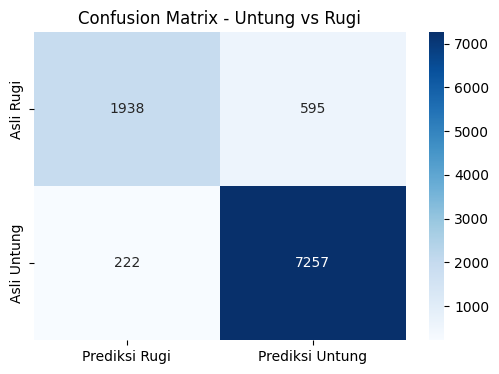

In [ ]:
print("\n--- HASIL EVALUASI KLASIFIKASI ---")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test_clf, y_pred_clf) * 100:.2f}%\n")
print("Detail Performa (Classification Report):")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Rugi (0)', 'Untung (1)']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Rugi', 'Prediksi Untung'],
            yticklabels=['Asli Rugi', 'Asli Untung'])
plt.title('Confusion Matrix - Untung vs Rugi')
plt.show()

In [ ]:
import pandas as pd

# ==========================================
# 1. FORM INPUT UI COLAB (Klasifikasi)
# (Ubah angka di panel sebelah kanan cell ini!)
# ==========================================
# @title 🛒 Detektor Status Untung/Rugi

Sales_USD = 500 # @param {type:"number"}
Diskon_Persen = 60 # @param {type:"slider", min:0, max:100, step:1}
Biaya_Kirim_USD = 200 # @param {type:"number"}
Kuantitas = 5 # @param {type:"integer"}

Kategori = 'Technology' # @param ["Furniture", "Office Supplies", "Technology"]
Sub_Kategori = 'Phones' # @param ["Accessories", "Appliances", "Art", "Binders", "Bookcases", "Chairs", "Copiers", "Envelopes", "Fasteners", "Furnishings", "Labels", "Machines", "Paper", "Phones", "Storage", "Supplies", "Tables"]
Segment = 'Home Office' # @param ["Consumer", "Corporate", "Home Office"]
Region = 'Southeast Asia' # @param ["Central", "North", "South", "East", "West", "Southeast Asia", "Oceania", "EMEA", "Africa", "Canada", "Caribbean", "Central Asia", "North Asia"]
Market = 'APAC' # @param ["APAC", "EU", "US", "LATAM", "EMEA", "Africa", "Canada"]
Ship_Mode = 'Standard Class' # @param ["Standard Class", "Second Class", "First Class", "Same Day"]
Order_Priority = 'Medium' # @param ["Low", "Medium", "High", "Critical"]

# Masukkan ke dictionary (Ubah persentase diskon jadi desimal)
user_input_clf = {
    'sales': [Sales_USD],
    'discount': [Diskon_Persen / 100.0],
    'quantity': [Kuantitas],
    'shipping_cost': [Biaya_Kirim_USD],
    'ship_mode': [Ship_Mode],
    'order_priority': [Order_Priority],
    'segment': [Segment],
    'market': [Market],
    'region': [Region],
    'category': [Kategori],
    'sub_category': [Sub_Kategori]
}

# ==========================================
# 2. PROSES PREDIKSI (KLASIFIKASI)
# ==========================================
df_input_clf = pd.DataFrame(user_input_clf)

# Feature Engineering
df_input_clf['shipping_cost_ratio'] = df_input_clf['shipping_cost'] / df_input_clf['sales']
df_input_clf['discount_impact'] = df_input_clf['discount'] * df_input_clf['sales']
df_input_clf['total_cost_spent'] = df_input_clf['sales'] + df_input_clf['shipping_cost']

# Encoding & Penyesuaian Kolom
df_input_encoded_clf = pd.get_dummies(df_input_clf)
training_columns_clf = X_train_scaled_clf.columns
df_input_encoded_clf = df_input_encoded_clf.reindex(columns=training_columns_clf, fill_value=0)

# Scaling menggunakan scaler_clf
df_input_scaled_clf = df_input_encoded_clf.copy()
df_input_scaled_clf[num_cols_clf] = scaler_clf.transform(df_input_encoded_clf[num_cols_clf])

# Prediksi Kelas (0 atau 1)
prediksi_status = xgb_classifier.predict(df_input_scaled_clf)[0]

# ==========================================
# 3. TAMPILAN OUTPUT
# ==========================================
print("==========================================")
print(f"🎯 OUTPUT MODEL: {prediksi_status}")
print("==========================================")

if prediksi_status == 1:
    print("✅ KESIMPULAN: UNTUNG (1) - Transaksi ini aman untuk disetujui.")
else:
    print("🚨 KESIMPULAN: RUGI (0) - Peringatan! Transaksi ini berpotensi merugikan perusahaan.")

🎯 OUTPUT MODEL: 0
🚨 KESIMPULAN: RUGI (0) - Peringatan! Transaksi ini berpotensi merugikan perusahaan.


In [ ]:
import joblib
import os

# Tentukan folder penyimpanan di Google Drive (menggunakan folder yang sama dengan sebelumnya)
save_dir = '/content/drive/MyDrive/Dataset/'

# 1. Simpan Model XGBoost Classifier
joblib.dump(xgb_classifier, f'{save_dir}xgboost_clf_model.pkl')

# 2. Simpan Scaler Numerik untuk Klasifikasi
joblib.dump(scaler_clf, f'{save_dir}scaler_clf.pkl')

# 3. Simpan Daftar Kolom Training untuk Klasifikasi
joblib.dump(list(X_train_scaled_clf.columns), f'{save_dir}training_columns_clf.pkl')

print("✅ SUKSES! Model Klasifikasi, Scaler, dan Daftar Kolom berhasil disimpan di Google Drive.")
print(f"Lokasi file: {save_dir}")

✅ SUKSES! Model Klasifikasi, Scaler, dan Daftar Kolom berhasil disimpan di Google Drive.
Lokasi file: /content/drive/MyDrive/Dataset/
